In [1]:
import numpy as np
from seaborn import kdeplot
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")

In [2]:
budget = 4 ** 8
conditioning_list = [4 ** i for i in range(9)]

wds_nn = np.zeros((10, len(conditioning_list)))
wds_ker = np.zeros((10, len(conditioning_list)))
wds_sde = np.zeros((10, len(conditioning_list)))
wds_mcmc = np.zeros((10, len(conditioning_list)))
wds_nn_std = np.zeros((10, len(conditioning_list)))
wds_ker_std = np.zeros((10, len(conditioning_list)))
wds_sde_std = np.zeros((10, len(conditioning_list)))
wds_mcmc_std = np.zeros((10, len(conditioning_list)))
for i in range(1,11):
    output_root = "budget_results"
    output_dir = os.path.join(output_root, f"ode_{i}")
    wd_nn_array = np.load(os.path.join(output_dir, "wd_nn_array_mean.npy"))
    wd_ker_array = np.load(os.path.join(output_dir, "wd_ker_array_mean.npy"))
    wd_sde_array = np.load(os.path.join(output_dir, "wd_nn_sde_array_mean.npy"))
    wd_mcmc_array = np.load(os.path.join(output_root, f"wd_mcmc_array_mean_{i}.npy"))
    wd_nn_std = np.load(os.path.join(output_dir, "wd_nn_array_std.npy"))
    wd_ker_std = np.load(os.path.join(output_dir, "wd_ker_array_std.npy"))
    wd_sde_std = np.load(os.path.join(output_dir, "wd_nn_sde_array_std.npy"))
    wd_mcmc_std = np.load(os.path.join(output_root, f"wd_mcmc_array_std_{i}.npy"))

    wds_nn[i-1, :] = wd_nn_array
    wds_ker[i-1, :] = wd_ker_array
    wds_sde[i-1, :] = wd_sde_array
    wds_mcmc[i-1, :] = wd_mcmc_array
    wds_nn_std[i-1, :] = wd_nn_std
    wds_ker_std[i-1, :] = wd_ker_std
    wds_sde_std[i-1, :] = wd_sde_std
    wds_mcmc_std[i-1, :] = wd_mcmc_std

In [7]:
wds_mcmc

array([[0.05290925, 0.23546455, 0.6631841 , 0.5068127 , 1.15645582,
        2.20229451, 2.64082624, 2.82613536, 3.6707236 ],
       [0.28008103, 0.37884637, 0.46410857, 0.51725403, 1.10269607,
        2.24145032, 2.58839565, 2.85501333, 3.67143537],
       [0.27588399, 0.45309981, 0.48963151, 0.61005145, 1.19264518,
        2.22589403, 2.61722173, 2.83712987, 3.66506527],
       [0.02815785, 0.41307995, 0.32085041, 0.64158583, 1.18609545,
        2.28747082, 2.64520806, 2.8195313 , 3.66513485],
       [0.09814042, 0.22516525, 0.50457608, 0.53773664, 1.15356216,
        2.13788577, 2.60320112, 2.84036775, 3.6592864 ],
       [0.35805567, 0.57343103, 0.35258236, 0.61301804, 1.08612211,
        2.11720196, 2.69136737, 2.84320499, 3.67902754],
       [0.05980432, 0.57766354, 0.57745365, 0.65928719, 1.18968639,
        2.20322183, 2.6472025 , 2.8710346 , 3.6705277 ],
       [0.04589551, 0.21935727, 0.34467176, 0.54620679, 1.20427657,
        2.16022745, 2.63095989, 2.83200296, 3.68187183],


In [3]:
wd_means = np.mean(wds_nn, axis=0)
wd_stds = np.mean(wds_nn_std, axis=0)

wd_sde_means = np.mean(wds_sde, axis=0)
wd_sde_stds = np.mean(wds_sde_std, axis=0)

wd_ker_means = np.mean(wds_ker, axis=0)
wd_sde_stds = np.mean(wds_ker_std, axis=0)

In [4]:
wd_mcmc_means = np.mean(wds_mcmc, axis=0)
wd_mcmc_stds = np.mean(wds_nn_std, axis=0)

In [5]:
wd_mcmc_means

array([0.39857238, 0.40359991, 0.45128281, 0.57032543, 1.14760253,
       2.20295161, 2.63833363, 2.84226908, 3.67117578])

Text(0, 0.5, 'W2 Error')

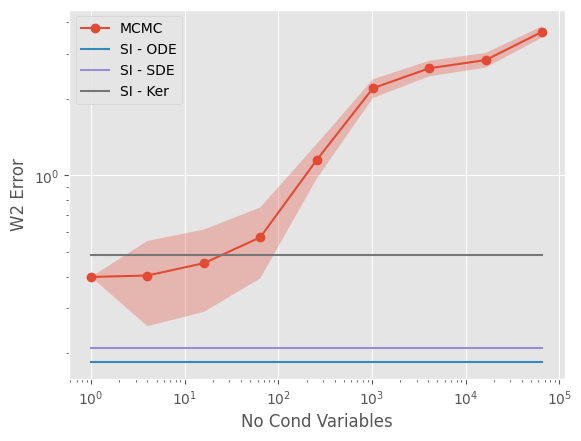

In [6]:
plt.plot(conditioning_list, wd_mcmc_means, label="MCMC", marker="o")
plt.fill_between(conditioning_list, wd_mcmc_means - wd_mcmc_stds, wd_mcmc_means + wd_mcmc_stds, alpha=0.3)
plt.plot(conditioning_list, np.mean(wd_means) * np.ones(9), label="SI - ODE")
plt.plot(conditioning_list, np.mean(wd_sde_means[:3]) * np.ones(9), label="SI - SDE")
plt.plot(conditioning_list, np.mean(wd_ker_means) * np.ones(9), label="SI - Ker")
# plt.axhline(np.mean(wd_nn_array).item(), label="SI")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("No Cond Variables")
plt.ylabel("W2 Error")

In [72]:
wd_sde_means

array([0.20439801, 0.25226009, 0.17210054,        nan,        nan,
              nan,        nan,        nan,        nan])

In [74]:
wd_means

array([0.1608222 , 0.20316621, 0.16861105, 0.17992752, 0.18792972,
       0.18537985, 0.18848692, 0.19065679, 0.18992296])

In [51]:
sde_samps = (np.load("nn_sde_results/ode_8/nn_samps.npy").T)[:, 1::2]
cond_ys = np.load("rej_results/_8/conditioning_ys.npy")

In [62]:
cond_ys[54681]

np.float64(-4.251304863705817)

In [45]:
np.where(np.isnan(sde_samps))

(array([   1,   30,  104,  107,  108,  134,  134,  134,  256,  256,  264,
         278,  331,  344,  366,  366,  395,  420,  420,  425,  458,  540,
         541,  562,  582,  607,  607,  611,  614,  624,  631,  645,  650,
         669,  690,  701,  702,  712,  756,  765,  822,  878,  878,  880,
         991,  998, 1031, 1049, 1084, 1085, 1104, 1121, 1143, 1147, 1195,
        1198, 1199, 1201, 1264, 1265, 1287, 1297, 1300, 1314, 1316, 1322,
        1322, 1322, 1398, 1405, 1416, 1495, 1495, 1496]),
 array([31066, 19053, 52628, 22972, 53908,  1793, 11435, 48737,  5716,
        16447, 32770, 34110,  1893, 39923,  2022, 53341, 22424, 15266,
        35916, 58626, 20913, 49123,   651, 40769, 48233, 56902, 62883,
        16874,  2790, 13575, 45410, 25892,  5008, 54681, 15293, 25914,
        25742, 55868, 18353, 59784, 23901, 44333, 58054, 64740, 38009,
        47738, 41999, 61091, 59960, 49395,  9653, 17925, 48972, 45092,
        28594, 38530,  3843, 12114, 26312, 25771, 40595, 56133, 21706,
 

In [47]:
sde_samps[1, 31067]

np.float32(-0.95338607)

In [48]:
sde_samps

array([[ 0.6583511 ,  0.18071322,  1.407213  , ...,  1.6888976 ,
         5.2858443 ,  4.9931693 ],
       [ 1.8063327 ,  0.8296939 , -0.32966435, ...,  2.8496559 ,
        -6.417577  ,  4.843935  ],
       [ 2.1963878 ,  0.03590939,  1.3216642 , ...,  1.6077602 ,
        -5.4005194 ,  2.9248238 ],
       ...,
       [-1.548253  ,  0.63232356, -0.576714  , ..., -2.6135833 ,
        -6.5785584 ,  4.270259  ],
       [-0.04937937,  1.647813  , -1.149564  , ...,  2.1621032 ,
         5.764621  ,  4.0442314 ],
       [ 0.7568452 ,  1.5267366 , -0.18782368, ...,  2.5003333 ,
        -5.5006657 ,  3.9063141 ]], shape=(1500, 65536), dtype=float32)

In [15]:
mcmc_samps = np.load("mcmc_results/mcmc_results_5/mcmc_samps_65536_1.npy")
cond_var = np.load("mcmc_results/mcmc_results_5/cond_vars_1.npy")

In [19]:
rej_samps = np.load("rej_results/_5/rej_samps.npy")
cond_ys = np.load("rej_results/_5/conditioning_ys.npy")
rej_samp = rej_samps[np.where(cond_ys == cond_var), :]

In [22]:
rej_samp.squeeze()

array([-5.71944733,  6.66190379, -5.61609647, ...,  5.65734256,
        6.55473123,  6.39110947], shape=(1500,))

In [25]:
mcmc_samps.squeeze()

array([-0.75533431, -0.70768018, -4.69034925, ..., -5.67056087,
       -5.67056087, -5.67056087], shape=(65536,))

<Axes: ylabel='Density'>

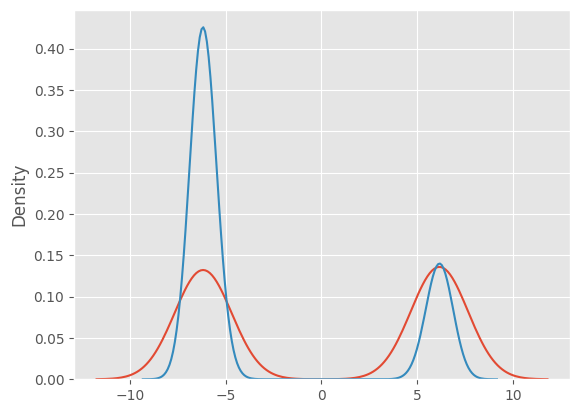

In [26]:
kdeplot(rej_samp.squeeze())
kdeplot(mcmc_samps.squeeze())

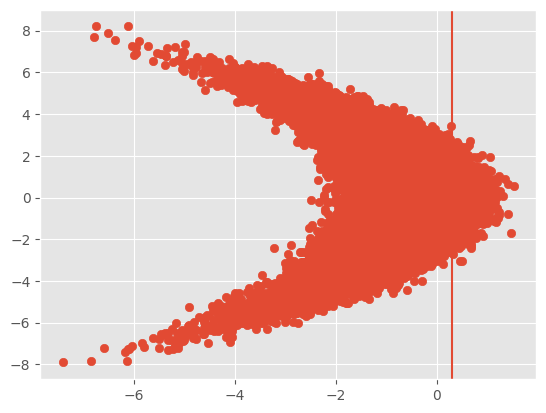

In [64]:
from triangular_transport.flows.methods.sampling import inf_train_gen
target_data = inf_train_gen(data="banana", rng=None, batch_size=budget)
plt.scatter(target_data[:, 0], target_data[:, 1])
plt.axvline(0.3)

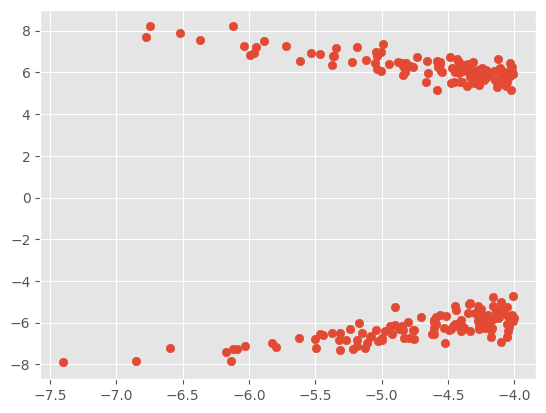

In [65]:
sub_data = target_data[np.where(target_data[:, 0] <= -4.0)[0]]
plt.scatter(sub_data[:, 0], sub_data[:, 1])

In [77]:
np.where(target_data[:, 0] >= 1.0)

(array([  200,  2304,  3889,  3964,  4859,  6934,  8541, 10894, 10989,
        11388, 11709, 13494, 15805, 16100, 16431, 17925, 18311, 19279,
        19826, 21210, 21255, 21778, 22481, 23786, 23842, 24328, 24884,
        25576, 26303, 26701, 30114, 30164, 30565, 31000, 31792, 32115,
        34320, 34836, 35196, 35322, 36159, 38090, 38249, 39510, 42396,
        43822, 46412, 46687, 46711, 46790, 47014, 48250, 48351, 49342,
        50649, 51254, 51893, 52166, 54206, 55660, 56929, 57522, 59152,
        60902, 61018, 62442, 62987, 63521]),)

In [76]:
np.max(target_data[:, 0])

np.float64(1.6780082795173554)

In [69]:
cond_vars[49]

np.float64(1.5765588923716285)

In [71]:
cond_vars[36]

np.float64(1.7298035568642156)

In [28]:
import pickle
with open("hyperparam_results/iteration_1/best_hyperparams.pkl", "rb") as f:
    best_hyperparams = pickle.load(f)
best_hyperparams

{'activation': np.str_('gelu'),
 'batch_size': 109,
 'hidden_layer': 516,
 'interpolant': np.str_('trig_interpolant'),
 'interpolant_der': np.str_('sigmoid_interpolant_der'),
 'num_hidden_layers': 6,
 'optimizer': np.str_('adagrad'),
 'peak_value': 0.000101913786}